# Utility Theory

The **mean-variance utility** of an asset (or portfolio) is

$$ U = \mathbb{E}[R] - \tfrac{1}{2} A\, \mathrm{Var}[R], $$

where $A$ is the investor's **risk-aversion coefficient**:

| Type           | $A$  | Behaviour                                           |
|----------------|------|-----------------------------------------------------|
| Risk-loving    | $<0$ | *prefers* variance; would pay a premium to gamble   |
| Risk-neutral   | $=0$ | indifferent to variance; only mean return matters    |
| Risk-averse    | $>0$ | dislikes variance; penalises volatile assets        |

Most real investors are risk-averse with $A$ between roughly 1 (aggressive) and 10 (very conservative).

**Note.** `Var[R]` here is *variance of returns* — not Value at Risk. The two are unrelated despite the abbreviation collision.

This notebook covers:

1. Loading data.
2. EDA on per-asset means and variances — the two inputs to the utility function.
3. Per-asset utility for three investor archetypes.
4. Comparing utility distributions visually.
5. The utility-maximising allocation between cash and a single risky asset (`max_utility`).

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from portfolio.data import DataIngestion
from portfolio.models import get_utility, max_utility

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

ingestion = DataIngestion()
all_prices = ingestion.get_all_prices()
all_returns = DataIngestion.compute_returns(all_prices)


[                       0%                       ]


[*                      2%                       ]  2 of 122 completed


[*                      2%                       ]  3 of 122 completed


[*                      3%                       ]  4 of 122 completed


[**                     4%                       ]  5 of 122 completed

...


[**********************97%********************** ]  118 of 122 completed


[**********************98%********************** ]  119 of 122 completed


[**********************98%********************** ]  120 of 122 completed


[**********************99%***********************]  121 of 122 completed


[*********************100%***********************]  122 of 122 completed

## 2. EDA — what the utility function sees

The utility of asset $i$ depends on two numbers: $\mathbb{E}[R_i]$ and $\mathrm{Var}[R_i]$. Looking at both side by side makes it clear which assets are likely to win in a risk-averse comparison and which in a risk-loving one.

In [2]:
asset_stats = pd.DataFrame({
    "mean_return": all_returns.mean(),
    "variance": all_returns.var(),
})
asset_stats["std"] = np.sqrt(asset_stats["variance"])
asset_stats.describe()

,mean_return,variance,std
count,122.000000,1.220000e+02,122.000000
mean,0.003285,5.196233e-03,0.056044
std,0.016612,8.605937e-03,0.045522
min,-0.033676,3.713495e-08,0.000193
25%,-0.002958,5.665694e-04,0.023803
50%,0.001064,1.943564e-03,0.044080
75%,0.005354,5.542356e-03,0.074433
max,0.113226,5.411541e-02,0.232627


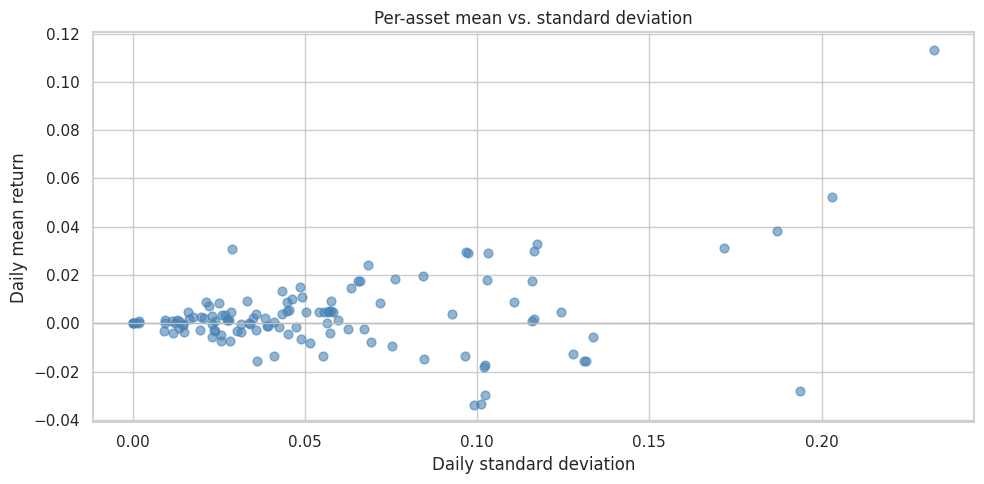

In [3]:
fig, ax = plt.subplots()
ax.scatter(asset_stats["std"], asset_stats["mean_return"],
           s=40, alpha=0.6, color="steelblue")
ax.axhline(0, color="#bbb", linewidth=1)
ax.set_xlabel("Daily standard deviation")
ax.set_ylabel("Daily mean return")
ax.set_title("Per-asset mean vs. standard deviation")
fig.tight_layout()
plt.show()

## 3. Per-asset utility for three investor archetypes

`get_utility(prices, A)` evaluates `U = E[r] - 0.5 * A * Var[r]` for every asset and returns a Series indexed by ticker.

In [4]:
utility_loving = get_utility(all_prices, risk_aversion=-1.0)
utility_neutral = get_utility(all_prices, risk_aversion=0.0)
utility_averse = get_utility(all_prices, risk_aversion=3.0)

comparison = pd.DataFrame({
    "loving (A = -1)": utility_loving,
    "neutral (A = 0)": utility_neutral,
    "averse (A = 3)": utility_averse,
}).sort_values("averse (A = 3)", ascending=False)
comparison.head(10)

,loving (A = -1),neutral (A = 0),averse (A = 3)
Ticker,,,
UP39665-USD,7.616559e+09,7.616559e+09,7.616559e+09
PLU,5.821058e+03,5.815872e+03,5.800312e+03
JU-USD,1.885731e+03,1.885627e+03,1.885313e+03
ZEC-USD,8.708209e+02,8.690839e+02,8.638729e+02
MRVU,5.367581e+02,5.355808e+02,5.320490e+02
MVLL,4.877964e+02,4.866047e+02,4.830295e+02
GTAO,4.416413e+02,4.402974e+02,4.362657e+02
ARMG,4.249848e+02,4.232735e+02,4.181394e+02
LUNL,2.868527e+02,2.824450e+02,2.692219e+02


### Visualising the three archetypes

Plotting the utility distributions side-by-side shows the qualitative effect of risk aversion: as $A$ grows, the high-variance tail of the per-asset utility distribution gets compressed downwards.

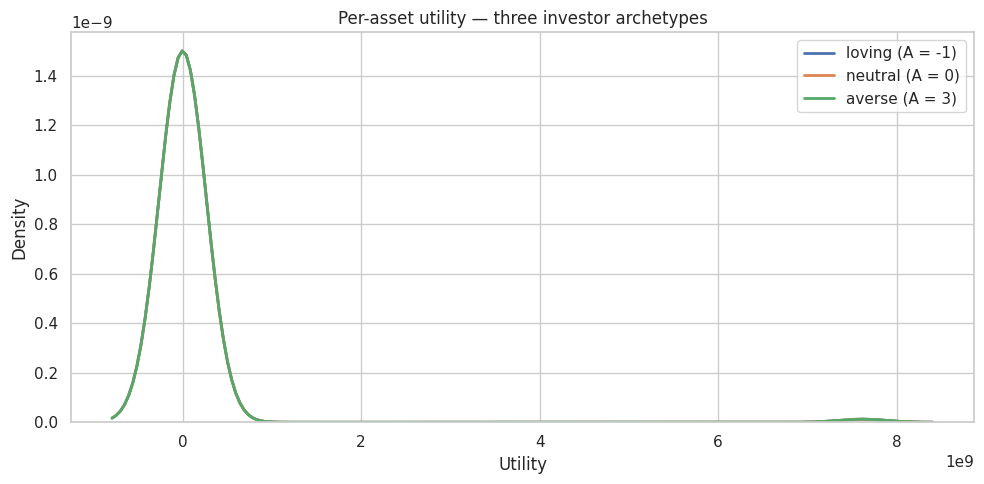

In [5]:
fig, ax = plt.subplots()
for label, series in [
    ("loving (A = -1)", utility_loving),
    ("neutral (A = 0)", utility_neutral),
    ("averse (A = 3)", utility_averse),
]:
    sns.kdeplot(series, label=label, ax=ax, linewidth=2)
ax.set_title("Per-asset utility — three investor archetypes")
ax.set_xlabel("Utility")
ax.legend()
fig.tight_layout()
plt.show()

### Sweep over a continuous range of risk-aversion values

Tracing utility as a function of $A$ for one asset shows the linear-in-$A$ structure of the formula directly. Volatile assets have steep negative slopes; stable assets have flat lines.

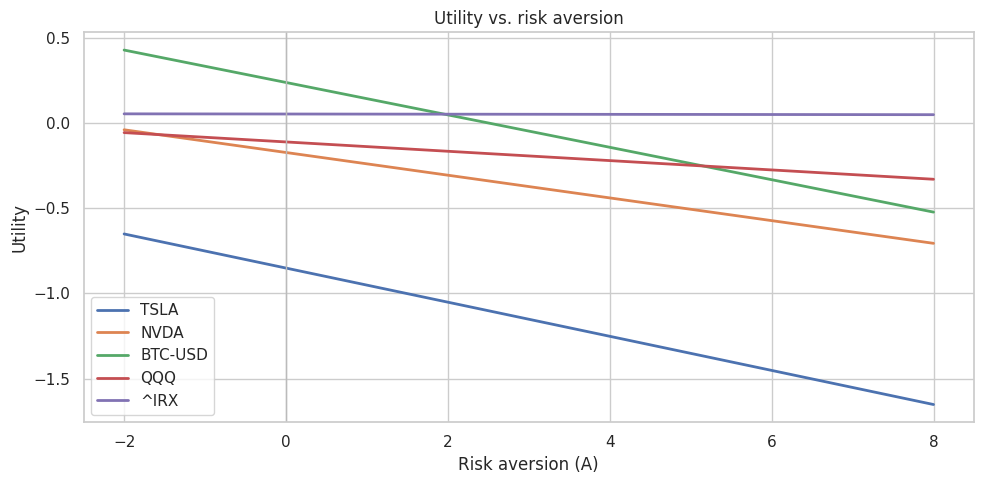

In [6]:
tickers_to_plot = ["TSLA", "NVDA", "BTC-USD", "QQQ", "^IRX"]
aversion_grid = np.linspace(-2, 8, 41)

fig, ax = plt.subplots()
for ticker in tickers_to_plot:
    series = pd.Series([
        get_utility(all_prices, risk_aversion=a)[ticker]
        for a in aversion_grid
    ], index=aversion_grid)
    series.plot(ax=ax, label=ticker, linewidth=2)
ax.axvline(0, color="#bbb", linewidth=1)
ax.set_xlabel("Risk aversion (A)")
ax.set_ylabel("Utility")
ax.set_title("Utility vs. risk aversion")
ax.legend()
fig.tight_layout()
plt.show()

## 4. Optimal allocation between cash and one risky asset

Given a risky asset with expected return $\mathbb{E}[r]$ and variance $\sigma^2$, plus a risk-free rate $r_f$, the optimal allocation to the risky asset is

$$ y^\star = \frac{\mathbb{E}[r] - r_f}{A\, \sigma^2}. $$

Substituting back gives the maximum utility

$$ U^\star = r_f + y^\star (\mathbb{E}[r] - r_f) - \tfrac{1}{2} A\, (y^\star)^2 \sigma^2. $$

`max_utility` evaluates $U^\star$ for every asset. Higher Sharpe-ratio assets — high excess return per unit of variance — produce a higher $U^\star$.

In [7]:
RISK_FREE_RATE = 0.04
RISK_AVERSION = 3.0

u_star = max_utility(
    all_prices,
    risk_aversion=RISK_AVERSION,
    risk_free_rate=RISK_FREE_RATE,
).sort_values(ascending=False)
u_star.head(10)

Ticker
UP39665-USD     7.089978e+17
JU-USD          2.831259e+06
PLU             5.434573e+05
ZEC-USD         3.623291e+04
MRVU            2.030119e+04
MVLL            1.655498e+04
GTAO            1.201895e+04
ARMG            8.722453e+03
TAO22974-USD    8.619937e+03
LUNL            1.507867e+03
dtype: float64

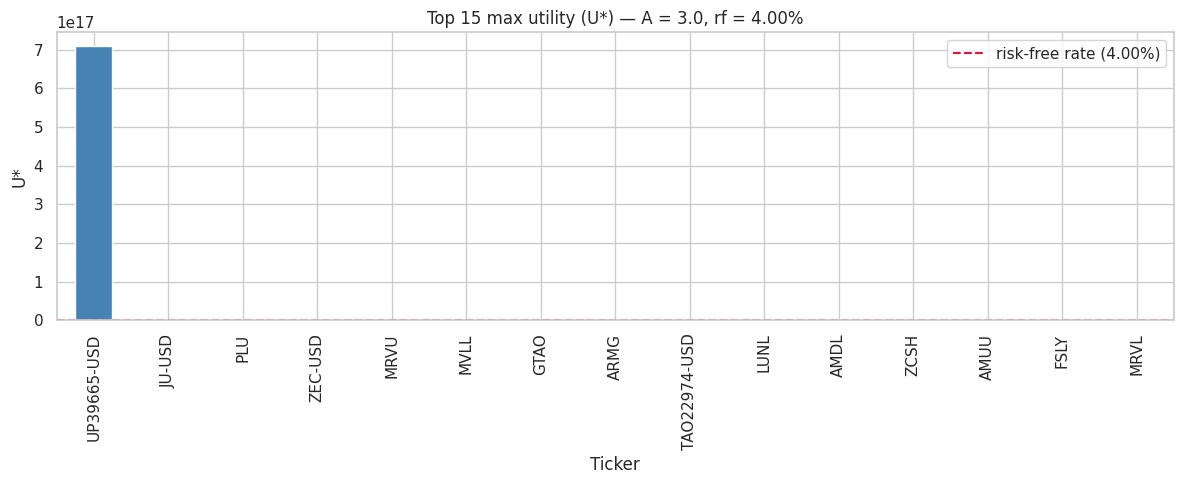

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
u_star.head(15).plot.bar(ax=ax, color="steelblue")
ax.axhline(RISK_FREE_RATE, color="crimson", linestyle="--",
           label=f"risk-free rate ({RISK_FREE_RATE:.2%})")
ax.set_title(f"Top 15 max utility (U*) — A = {RISK_AVERSION}, rf = {RISK_FREE_RATE:.2%}")
ax.set_ylabel("U*")
ax.set_xlabel("Ticker")
ax.legend()
fig.tight_layout()
plt.show()

Note the floor at the risk-free rate: $U^\star \geq r_f$ always, because the investor can choose $y^\star = 0$ and earn $r_f$ on cash. As with MPT, these results are sensitive to estimation error in $\mathbb{E}[r]$ and $\sigma^2$ — interpret the ranking as a teaching exercise, not a portfolio recommendation.

## 5. Utility optimisation across different risk-aversion levels

How does the *optimised* utility $U^\star$ — the result of `max_utility` — change as the investor becomes more or less risk-averse? The optimal risky-asset weight $y^\star$ is inversely proportional to $A$:

$$ y^\star = \frac{\mathbb{E}[r] - r_f}{A\, \sigma^2}. $$

So as $A$ grows, the investor allocates less to the risky asset and the optimised utility $U^\star$ falls toward the risk-free rate. Plotting $y^\star$ and $U^\star$ against $A$ for a few representative assets makes that trade-off concrete.

In [9]:
from pypfopt import expected_returns, risk_models

tickers_to_compare = ["TSLA", "NVDA", "BTC-USD", "QQQ", "^IRX"]
aversion_grid = np.linspace(0.5, 10.0, 40)
RISK_FREE_RATE = 0.04

er = expected_returns.mean_historical_return(all_prices)
var = pd.Series(np.diag(risk_models.sample_cov(all_prices).to_numpy()),
                index=all_prices.columns)

y_star = pd.DataFrame({
    ticker: (er[ticker] - RISK_FREE_RATE) / (aversion_grid * var[ticker])
    for ticker in tickers_to_compare
}, index=aversion_grid)
y_star.index.name = "A"
y_star.head()

,TSLA,NVDA,BTC-USD,QQQ,^IRX
A,,,,,
0.500000,-8.893583,-3.181561,2.091260,-5.485275,28.026382
0.743590,-5.980168,-2.139326,1.406192,-3.688374,18.845326
0.987179,-4.504542,-1.611440,1.059210,-2.778256,14.195181
1.230769,-3.613018,-1.292509,0.849574,-2.228393,11.385718
1.474359,-3.016085,-1.078964,0.709210,-1.860224,9.504599


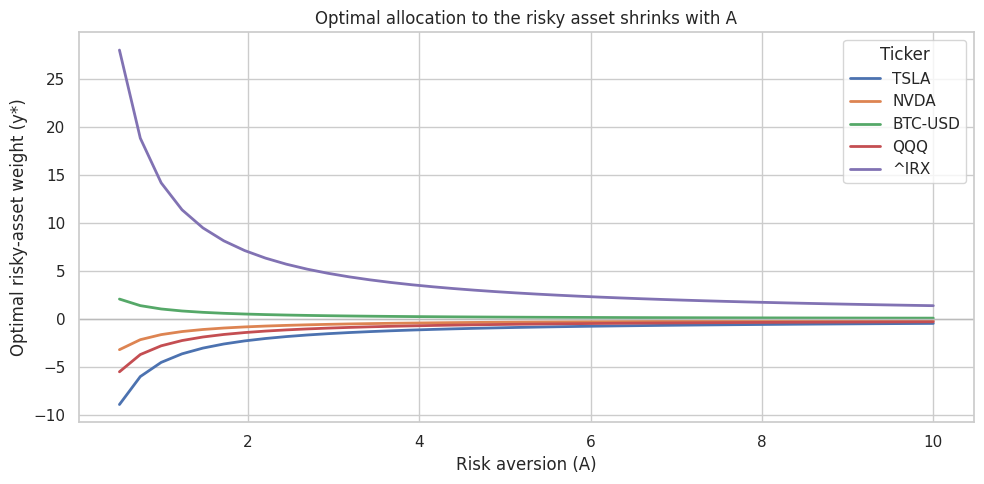

In [10]:
fig, ax = plt.subplots()
y_star.plot(ax=ax, linewidth=2)
ax.axhline(0, color="#bbb", linewidth=1)
ax.set_xlabel("Risk aversion (A)")
ax.set_ylabel("Optimal risky-asset weight (y*)")
ax.set_title("Optimal allocation to the risky asset shrinks with A")
ax.legend(title="Ticker")
fig.tight_layout()
plt.show()

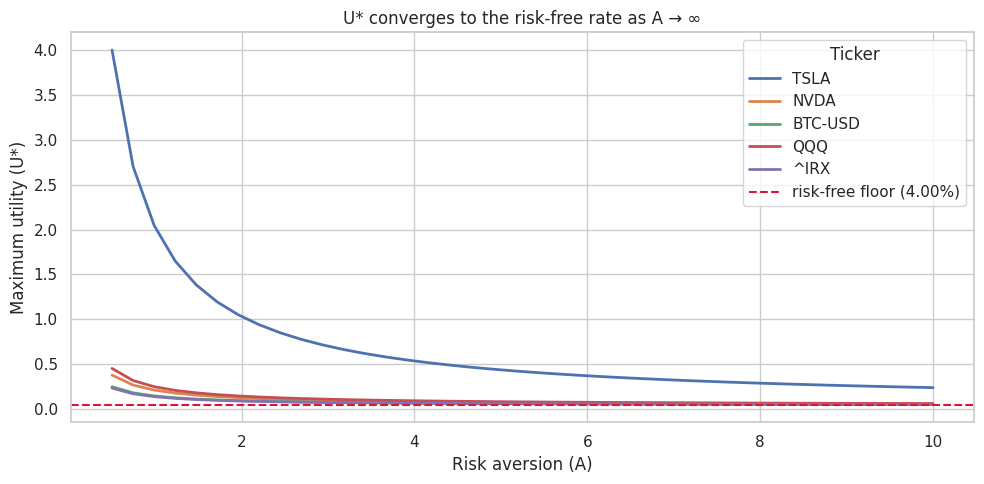

In [11]:
u_star_grid = pd.DataFrame({
    ticker: [
        max_utility(
            all_prices,
            risk_aversion=a,
            risk_free_rate=RISK_FREE_RATE,
        )[ticker]
        for a in aversion_grid
    ]
    for ticker in tickers_to_compare
}, index=aversion_grid)
u_star_grid.index.name = "A"

fig, ax = plt.subplots()
u_star_grid.plot(ax=ax, linewidth=2)
ax.axhline(RISK_FREE_RATE, color="crimson", linestyle="--",
           label=f"risk-free floor ({RISK_FREE_RATE:.2%})")
ax.set_xlabel("Risk aversion (A)")
ax.set_ylabel("Maximum utility (U*)")
ax.set_title("U* converges to the risk-free rate as A → ∞")
ax.legend(title="Ticker")
fig.tight_layout()
plt.show()

### Cross-section at three discrete risk-aversion levels

Comparing $U^\star$ across assets at $A = 1$ (aggressive), $A = 3$ (moderate), and $A = 8$ (conservative) shows two things at once:

- **Within each row**, $U^\star$ falls as $A$ grows.
- **Across rows**, low-volatility assets are far less sensitive to $A$ — their $U^\star$ barely moves — while volatile assets see steep drops.

In [12]:
discrete_levels = [1.0, 3.0, 8.0]
u_star_levels = pd.DataFrame({
    f"A = {a}": max_utility(
        all_prices,
        risk_aversion=a,
        risk_free_rate=RISK_FREE_RATE,
    )
    for a in discrete_levels
})
u_star_levels.loc[tickers_to_compare]

,A = 1.0,A = 3.0,A = 8.0
Ticker,,,
TSLA,2.021184,0.700395,0.287648
NVDA,0.208788,0.096263,0.061098
BTC-USD,0.144068,0.074689,0.053009
QQQ,0.246059,0.108686,0.065757
^IRX,0.136446,0.072149,0.052056


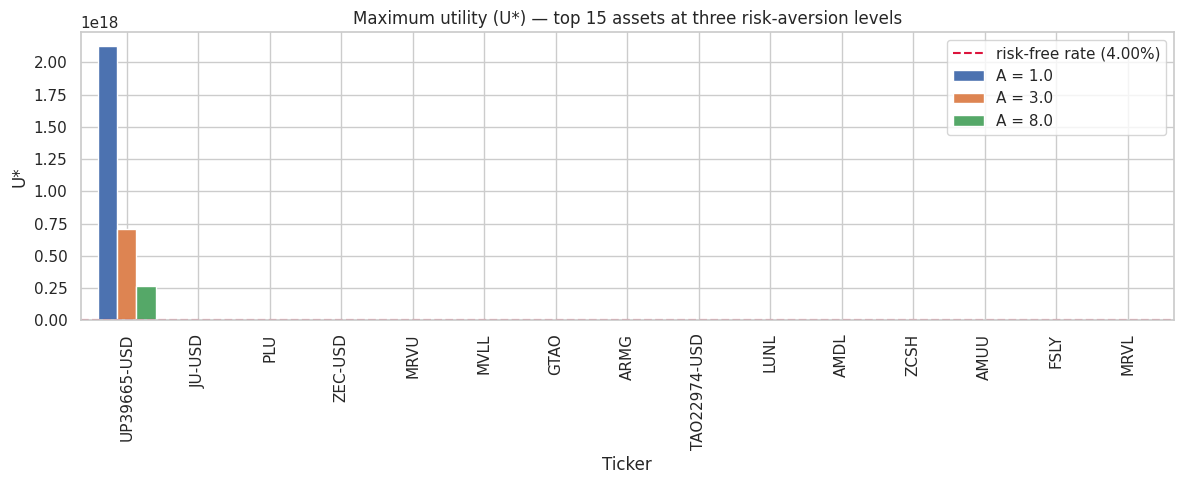

In [13]:
top = u_star_levels.sort_values("A = 3.0", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 5))
top.plot.bar(ax=ax, width=0.8)
ax.axhline(RISK_FREE_RATE, color="crimson", linestyle="--",
           label=f"risk-free rate ({RISK_FREE_RATE:.2%})")
ax.set_title("Maximum utility (U*) — top 15 assets at three risk-aversion levels")
ax.set_ylabel("U*")
ax.set_xlabel("Ticker")
ax.legend(title="")
fig.tight_layout()
plt.show()

**Reading the chart.** The aggressive investor (A = 1) gets a much higher optimised utility from the volatile, high-return assets than the conservative investor (A = 8) — but pays for it with a much larger position in those assets. The conservative investor's $U^\star$ for the same names is barely above the risk-free rate, because they would optimally hold almost all cash.